# Experiment: Baseline Panel Downstream Experiment

这个 notebook 对应 `scripts/trishift/analysis/baseline_panel.py`。

目的：
- 在统一口径下比较 `TriShift nearest/random`、`Scouter`、`GEARS`、`GenePert`、`Systema` baselines。
- 生成可直接用于论文主表和补充表的 summary / ranking / subgroup 结果。

建议：
- `adamson` 先用于 smoke test。
- `norman` 再查看 `subgroup` 分层表现。


In [1]:
from __future__ import annotations

import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "scripts").exists() and (repo_root.parent / "scripts").exists():
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

import scripts.trishift.analysis.baseline_panel as baseline_panel
importlib.reload(baseline_panel)

# Hide systema_corr_deg_r2 in this notebook's outputs.
baseline_panel.PANEL_METRICS = [m for m in baseline_panel.PANEL_METRICS if m != "systema_corr_deg_r2"]

run_baseline_panel = baseline_panel.run_baseline_panel
DEFAULT_MODEL_REQUESTS = baseline_panel.DEFAULT_MODEL_REQUESTS
PANEL_METRICS = baseline_panel.PANEL_METRICS

repo_root


WindowsPath('e:/CODE/trishift')

## Parameters

直接在这里改数据集、模型集合和 split。`systema_root` 一般留空，让脚本自动找最新结果。


In [2]:
dataset = "norman"  # adamson | norman | replogle_k562 | replogle_rpe1
models = [
    "trishift_nearest",
    "gears",
    "genepert",
    "scgpt",
    "systema_nonctl_mean",
    "systema_matching_mean",
]
split_ids = [1, 2, 3, 4, 5]
out_root = None
systema_root = None

result = run_baseline_panel(
    dataset=dataset,
    models=models,
    split_ids=split_ids,
    out_root=out_root,
    systema_root=systema_root,
)

print(f"out_dir: {result['out_dir']}")
print(f"panel metrics: {PANEL_METRICS}")


out_dir: E:\CODE\trishift\notebooks\artifacts\analysis\20260324_151504_baseline_panel_norman
panel metrics: ['pearson', 'nmse', 'deg_mean_r2', 'systema_corr_20de_allpert', 'scpram_r2_degs_mean_mean', 'scpram_r2_degs_var_mean', 'scpram_wasserstein_degs_sum']


## Summary Tables

先看总表和 ranking。`mean_pearson` 仍然是最直接的主排序参考。


In [3]:
display(result["summary_df"])
display(result["ranking_df"])
if not result["subgroup_df"].empty:
    display(result["subgroup_df"])


,dataset,model_name,label,n_rows,split_ids_used,metrics_path,mean_pearson,mean_nmse,mean_deg_mean_r2,mean_systema_corr_20de_allpert,mean_scpram_r2_degs_mean_mean,mean_scpram_r2_degs_var_mean,mean_scpram_wasserstein_degs_sum
0,norman,trishift_nearest,TriShift nearest,230,"1,2,3,4,5",E:\CODE\trishift\artifacts\results\norman\metr...,0.872425,0.238160,0.693888,0.777171,0.960521,0.533888,5.560348
1,norman,gears,GEARS,345,"1,2,3,4,5",E:\CODE\trishift\artifacts\results\gears\norma...,0.727998,0.526555,0.329416,0.437663,0.886038,NaN,11.397564
2,norman,genepert,GenePert,170,"1,2,3,4,5",E:\CODE\trishift\artifacts\results\genepert\no...,0.839052,0.416040,0.496155,0.683330,0.937080,NaN,10.309933
3,norman,systema_nonctl_mean,Systema nonctl-mean,230,"1,2,3,4,5",E:\CODE\trishift\artifacts\results\norman\syst...,0.652929,0.699585,0.109509,-0.261255,NaN,NaN,NaN
4,norman,systema_matching_mean,Systema matching-mean,230,"1,2,3,4,5",E:\CODE\trishift\artifacts\results\norman\syst...,0.864217,0.347817,0.549601,0.584600,NaN,NaN,NaN


,dataset,model_name,label,n_rows,split_ids_used,metrics_path,mean_pearson,mean_nmse,mean_deg_mean_r2,mean_systema_corr_20de_allpert,mean_scpram_r2_degs_mean_mean,mean_scpram_r2_degs_var_mean,mean_scpram_wasserstein_degs_sum
0,norman,trishift_nearest,TriShift nearest,230,"1,2,3,4,5",E:\CODE\trishift\artifacts\results\norman\metr...,0.872425,0.238160,0.693888,0.777171,0.960521,0.533888,5.560348
1,norman,systema_matching_mean,Systema matching-mean,230,"1,2,3,4,5",E:\CODE\trishift\artifacts\results\norman\syst...,0.864217,0.347817,0.549601,0.584600,NaN,NaN,NaN
2,norman,genepert,GenePert,170,"1,2,3,4,5",E:\CODE\trishift\artifacts\results\genepert\no...,0.839052,0.416040,0.496155,0.683330,0.937080,NaN,10.309933
3,norman,gears,GEARS,345,"1,2,3,4,5",E:\CODE\trishift\artifacts\results\gears\norma...,0.727998,0.526555,0.329416,0.437663,0.886038,NaN,11.397564
4,norman,systema_nonctl_mean,Systema nonctl-mean,230,"1,2,3,4,5",E:\CODE\trishift\artifacts\results\norman\syst...,0.652929,0.699585,0.109509,-0.261255,NaN,NaN,NaN


,dataset,model_name,label,subgroup,n_rows,mean_pearson,mean_nmse,mean_deg_mean_r2,mean_systema_corr_20de_allpert,mean_scpram_r2_degs_mean_mean,mean_scpram_r2_degs_var_mean,mean_scpram_wasserstein_degs_sum
0,norman,trishift_nearest,TriShift nearest,seen0,6,0.944359,0.130815,0.849167,0.917073,0.936267,0.390632,6.130675
1,norman,trishift_nearest,TriShift nearest,seen1,48,0.962918,0.098010,0.875014,0.929692,0.966424,0.487207,5.598991
2,norman,trishift_nearest,TriShift nearest,seen2,71,0.973237,0.097522,0.885357,0.946386,0.968786,0.521676,5.659639
3,norman,trishift_nearest,TriShift nearest,single,105,0.758777,0.403461,0.472745,0.585030,0.953619,0.571672,5.442953
4,norman,gears,GEARS,seen0,8,0.895935,0.298375,0.628542,0.768731,0.904356,NaN,12.462738
5,norman,gears,GEARS,seen1,81,0.811730,0.368681,0.496670,0.655634,0.889608,NaN,11.750191
6,norman,gears,GEARS,seen2,127,0.789980,0.418796,0.466134,0.604919,0.886754,NaN,11.579486
7,norman,gears,GEARS,single,129,0.603987,0.745925,0.071246,0.115603,0.881957,NaN,10.930990
8,norman,genepert,GenePert,seen0,1,0.953284,0.166936,0.743805,0.950741,0.902054,NaN,13.474790
9,norman,genepert,GenePert,seen1,23,0.949192,0.213237,0.719259,0.939568,0.923295,NaN,10.864490


## Artifacts

这里直接回看导出的图和文件路径。适合做论文表格/图的二次整理。


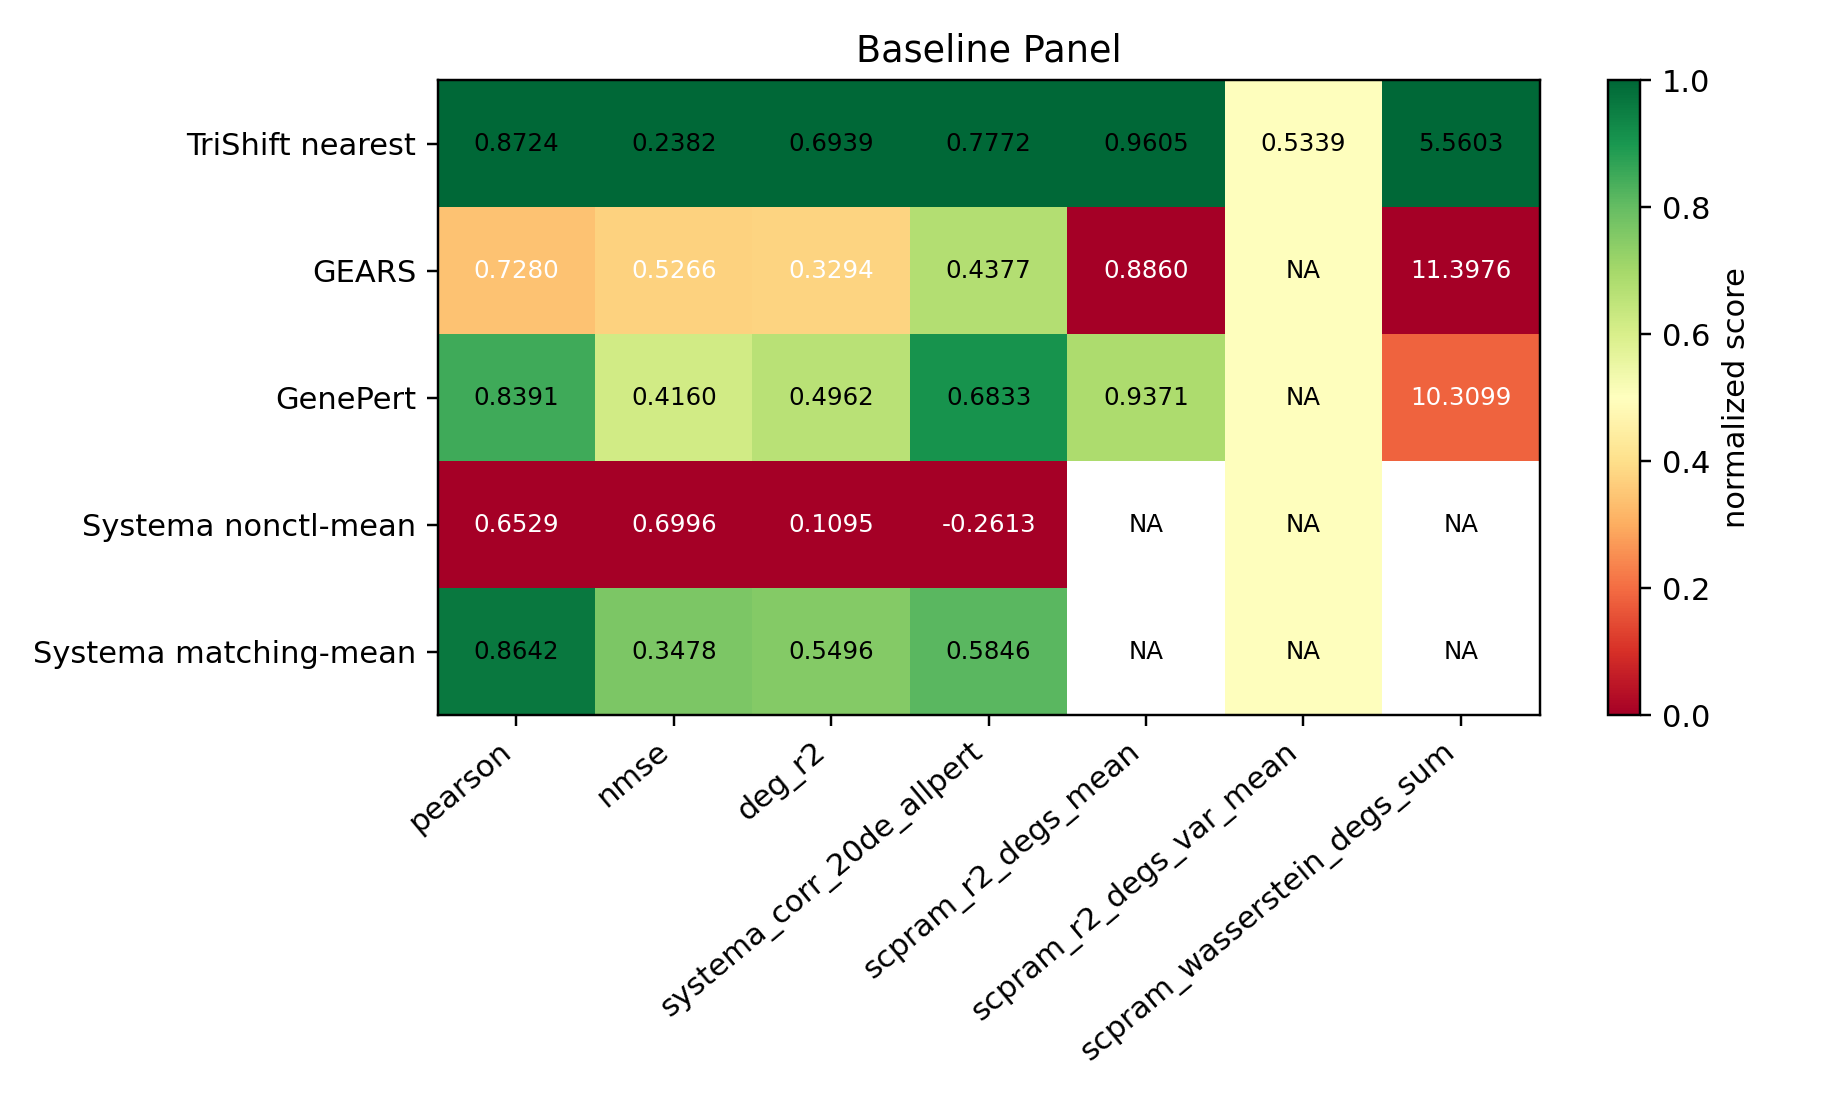

E:\CODE\trishift\notebooks\artifacts\analysis\20260324_151504_baseline_panel_norman\baseline_panel_raw.csv
E:\CODE\trishift\notebooks\artifacts\analysis\20260324_151504_baseline_panel_norman\baseline_panel_summary.csv
E:\CODE\trishift\notebooks\artifacts\analysis\20260324_151504_baseline_panel_norman\baseline_panel_ranking.csv
E:\CODE\trishift\notebooks\artifacts\analysis\20260324_151504_baseline_panel_norman\norman_subgroup_panel.csv
E:\CODE\trishift\notebooks\artifacts\analysis\20260324_151504_baseline_panel_norman\run_meta.json


In [4]:
out_dir = Path(result["out_dir"])
display(Image(filename=str(out_dir / "baseline_panel_heatmap.png")))

for path in [
    out_dir / "baseline_panel_raw.csv",
    out_dir / "baseline_panel_summary.csv",
    out_dir / "baseline_panel_ranking.csv",
    out_dir / "norman_subgroup_panel.csv",
    out_dir / "run_meta.json",
]:
    print(path)
